# 76. Minimum Window Substring

Given two strings **s** and **t** of **lengths** **m** and **n** respectively, **return the minimum window substring** of **s** such that every character in **t**(including duplicates) is included in the window**. If there is no such substring, return the empty string "".

The testcases will be generated such that the answer is unique.

## Example 1:

Input: s = "ADOBECODEBANC", t = "ABC"
Output: "BANC"
Explanation: The minimum window substring "BANC" includes 'A', 'B', and 'C' from string t.

## Example 2:

Input: s = "a", t = "a"
Output: "a"
Explanation: The entire string s is the minimum window.

## Example 3:

Input: s = "a", t = "aa"
Output: ""
Explanation: Both 'a's from t must be included in the window.
Since the largest window of s only has one 'a', return empty string.

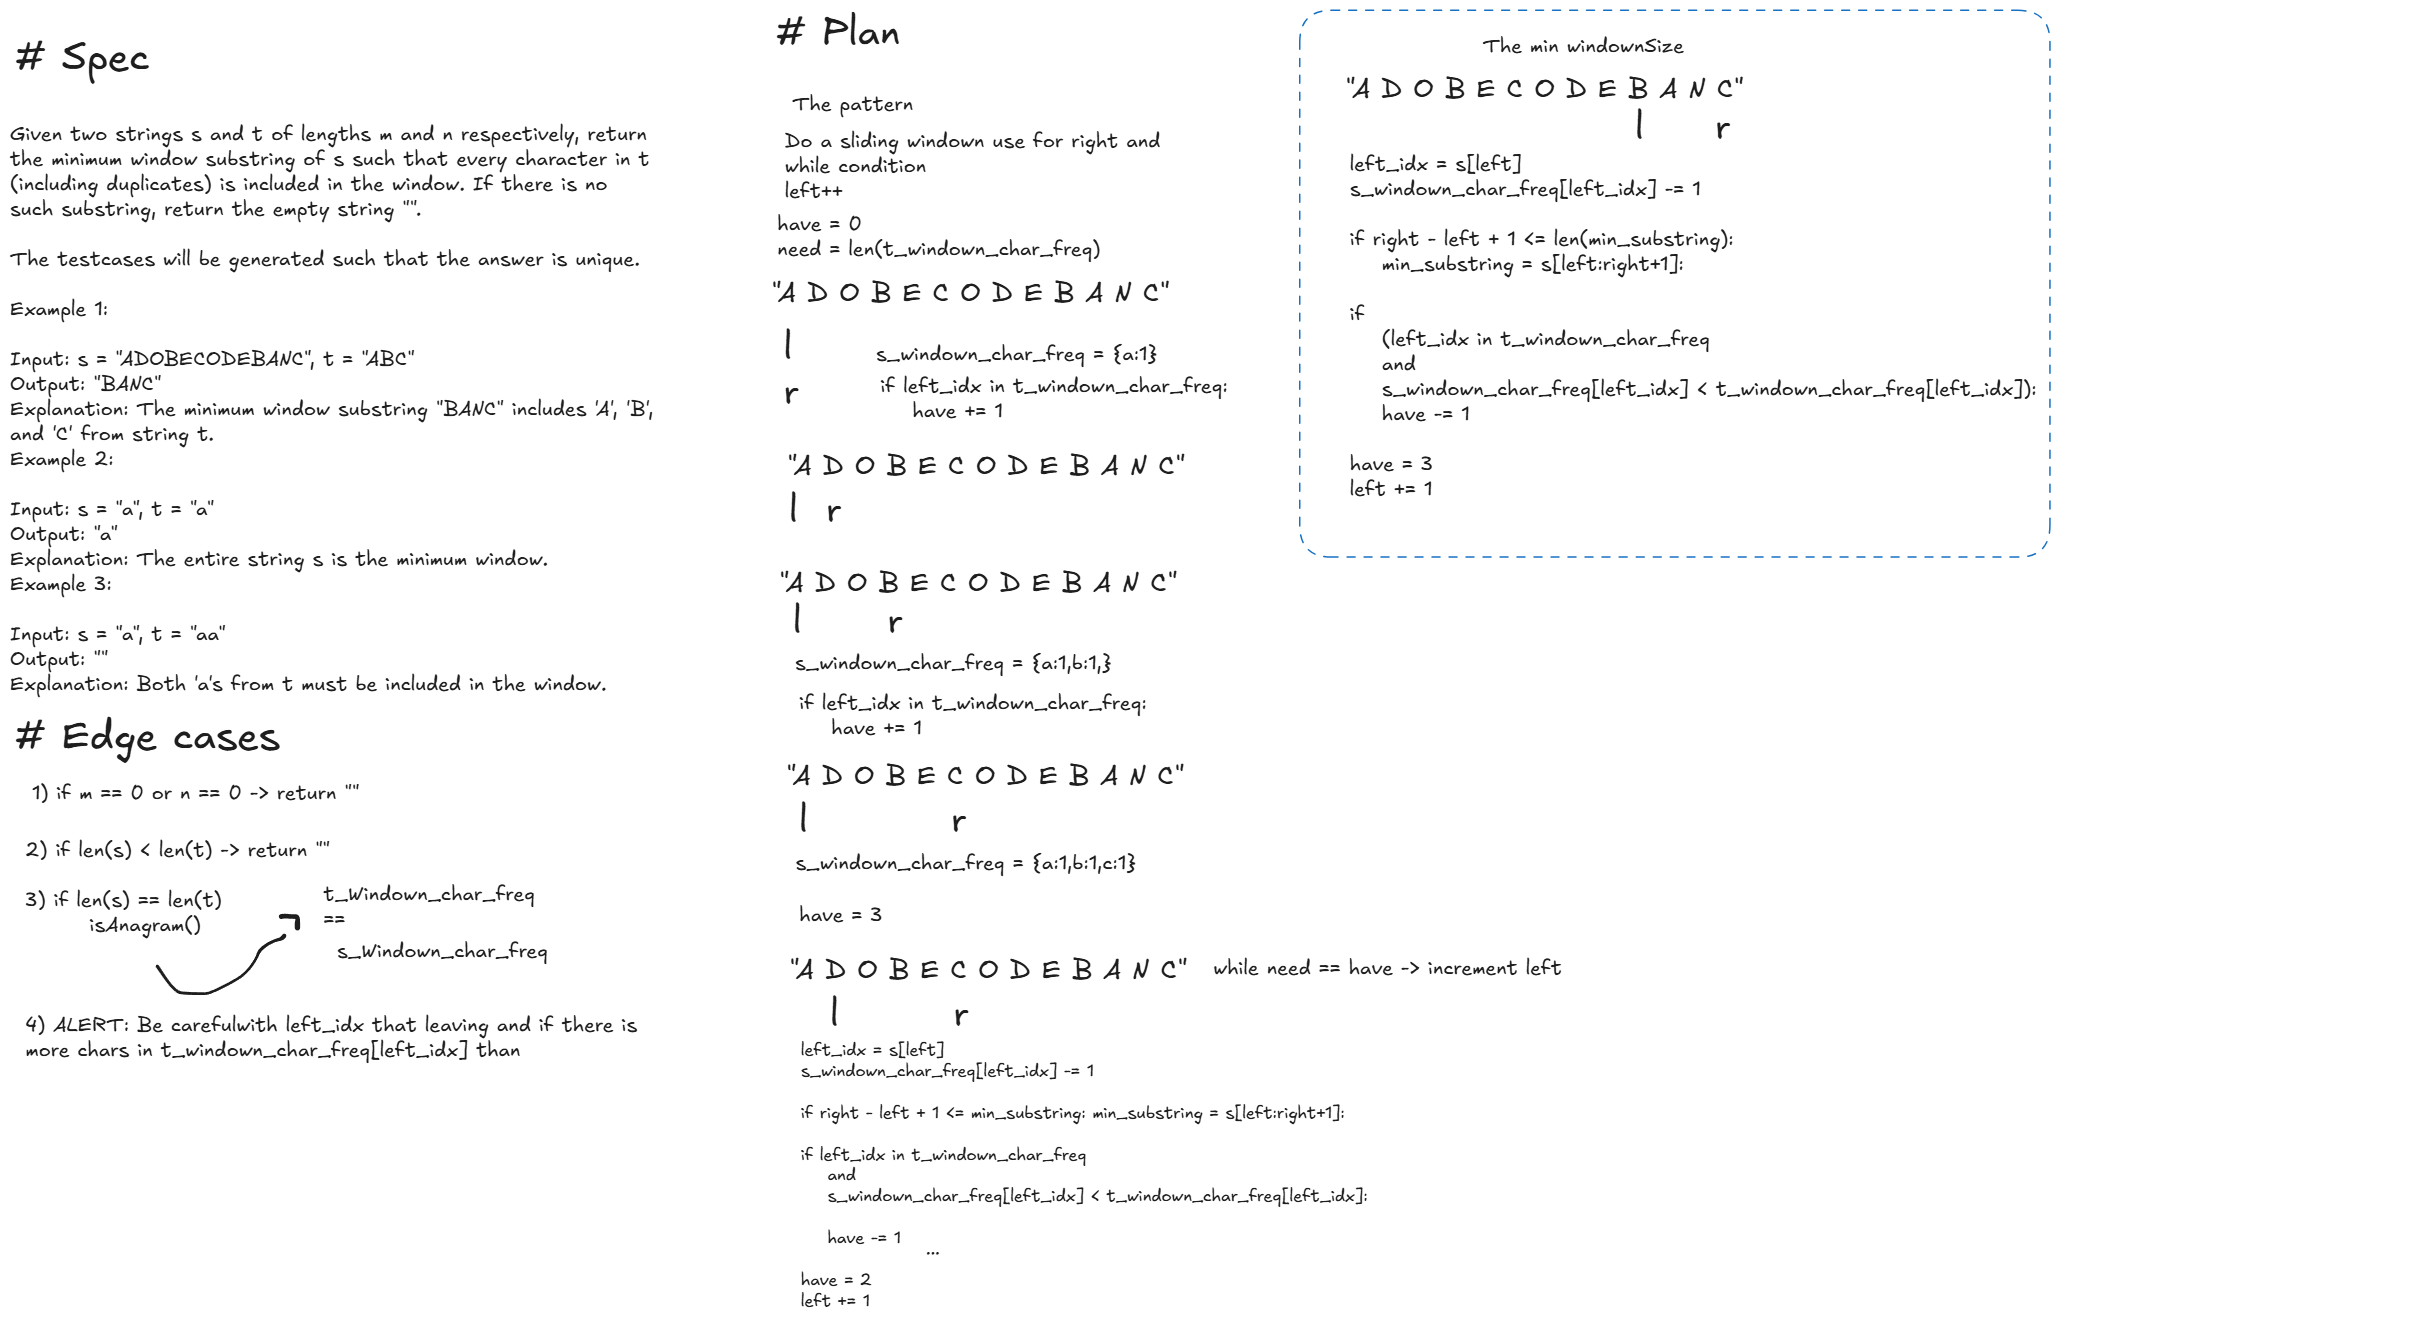

# Spec

- Temos que encontrar a menor substring em 's' que contenha todos os caracters de 't'
- dado os parametros s como a string maior e t a substring que estamos pesquisamos
- Retornaremos a substring tal que (right - left + 1) seja o menor possivel


## Edge cases

- if not s or not t:  return ''
- if len(s) < len(t) return ''

# Plan

S = "A D O B E C O D E B A N C"  t = "A B C"
     L
     R

A existing in t? :
left = 0
right += 1

S = "A D O B E C O D E B A N C"  t = "A B C"
     L R

windown_conut['D'] += 1


D existing in t? : no... 

S = "A D O B E C O D E B A N C"  t = "A B C"
     L     R  
     
B existing in t? : yes...

counter_t['B']

key vai ser o char valor sera tupla(total_caracters)

S = "A D O B E C O D E B A N C"  t = "A B C"
     L         R

counter_t = {
    'A':1, 'B':1 , 'C':1
}
total das somas dos caracters é o valor que precisamos assim temos uma sequencia

max_sequence = (left,right)

como atigimos vamos pular para o left do A para o proximo caracter alvo 'B'
e mantemos o right como esta

decrementamos o paracters 1 "A" 

S = "A D O B E C O D E B A N C"  t = "A B C"
           L   R         

S = "A D O B E C O D E B A N C B D A"  t = "A B C"
           L             R
        encontramos uma outra sequencia com tamanhio right - left + 1 == 8 < len(smaller_sequence) ?
        não entao continuamos 

S = "A D O B E C O D E B A N C B D A"  t = "A B C"
               L               R

S = "A D O B E C O D E B A N C B D A"  t = "A B C"
                         L     R

S = "A D O B E C O D E B A N C B D A"  t = "A B C"
                             L     R

smaller == 4 !

max_sequence = (left,right)

widown_count_t = {}


In [ ]:
class Solution:
    def windownSize(self, left:int, right:int)-> int:
        return right - left + 1

    def minWindow(self, s: str, t: str) -> str:
        """
        Find the minimum window substring in s that contains all characters from t
        
        Algorithm: Sliding Window with two pointers
        1. Create frequency map of characters in t
        2. Expand window (right pointer) until all chars from t are included
        3. Shrink window (left pointer) to find the minimum length
        4. Track the smallest valid window found
        
        Time: O(m + n) where m = len(s), n = len(t)
        Space: O(1) - at most 26 lowercase letters
        """
        # Edge cases
        if not s or not t or len(s) < len(t):
            return ''
        
        # Create frequency map of characters in t
        needed = {}  # How many of each char we need
        for char in t:
            needed[char] = needed.get(char, 0) + 1
        
        # Sliding window variables
        total_needed = len(needed)  # Number of unique chars we need
        total_have = 0  # Number of unique chars we have with desired frequency
        
        window_counts = {}  # Frequency map of current window
        left = 0
        result = tuple(float('inf'), 0, 0)  # (window length, left, right)

        # Expand window with right pointer
        for right in range(len(s)):
            # Add character from right to window
            char = s[right]
            window_counts[char] = window_counts.get(char, 0) + 1
            
            # If frequency of char matches needed frequency, increment formed
            
            if char in needed and window_counts[char] == needed[char]:
                total_have += 1
            
            while total_have == total_needed and left <= right:
                char = s[left]
                
                # Update result if current window is smaller
                windown_size = self.windownSize(left,right)
                if windown_size < result[0]:
                    result = (windown_size, left, right)
                
                # Remove left character from window
                window_counts[char] -= 1
                if char in needed and window_counts[char] < needed[char]:
                    total_have -= 1
                
                # Move left pointer
                left += 1
        size, left, right = result
        # Return the minimum window substring
        if size == float('inf'): 
            return ''
        return s[left: right + 1]